<a href="https://colab.research.google.com/github/monasolgi/Computer_vision/blob/main/_Using_hub_Bart_homer_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I created my own binary image classification dataset using images of Bart and Homer. First, I applied the provided BiT (TensorFlow Hub) model to this dataset and evaluated its performance. Then, I implemented two alternative models: a fully connected neural network (using flattened image inputs) and a convolutional neural network (CNN). I compared the results of these models to analyze how different architectures and input representations affect classification performance.

**Using hub_Bart_homer_dataset**

In [ ]:
#libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import os
import random
import shutil
import matplotlib.pyplot as plt

As an example of a state-of-the-art deep convolutional neural network, in this exercise we will use the Big Transfer (BiT) approach (see <a href="https://arxiv.org/abs/1912.11370">paper</a>) to build a binary image classifier. In case you are not familiar with tensorflow you can find more information in the <a href="https://www.tensorflow.org/tutorials">tensorflow tutorials</a>.

**Using the model**

To test the approach on your own image classification data set, upload your images as a zip file. The zip file must be called images.zip and contain a single folder "images" with subfolders "train" and "test". Both "train" and "test" must contain further subfolders "class1" and "class2", and these must contain the actual images. Images should be approximately square.



In [ ]:
#Upload zip file with image data.
#Existing zip files are cleared first to avoid file name clashes
from google.colab import files
!rm /content/*.zip
uploaded = files.upload()

rm: cannot remove '/content/*.zip': No such file or directory


Saving homer_bart_1.zip to homer_bart_1.zip


unzip file

In [ ]:
!unzip -o /content/homer_bart_1.zip -d /content/

Archive:  /content/homer_bart_1.zip
   creating: /content/homer_bart_1/
  inflating: /content/homer_bart_1/homer38.bmp  
  inflating: /content/homer_bart_1/bart58.bmp  
  inflating: /content/homer_bart_1/bart70.bmp  
  inflating: /content/homer_bart_1/homer10.bmp  
  inflating: /content/homer_bart_1/bart64.bmp  
  inflating: /content/homer_bart_1/homer119.bmp  
  inflating: /content/homer_bart_1/bart162.bmp  
  inflating: /content/homer_bart_1/homer124.bmp  
  inflating: /content/homer_bart_1/bart65.bmp  
  inflating: /content/homer_bart_1/bart71.bmp  
  inflating: /content/homer_bart_1/bart59.bmp  
  inflating: /content/homer_bart_1/bart67.bmp  
  inflating: /content/homer_bart_1/homer13.bmp  
  inflating: /content/homer_bart_1/bart73.bmp  
  inflating: /content/homer_bart_1/bart98.bmp  
  inflating: /content/homer_bart_1/bart161.bmp  
  inflating: /content/homer_bart_1/bart149.bmp  
  inflating: /content/homer_bart_1/bart148.bmp  
  inflating: /content/homer_bart_1/bart160.bmp  
  in

creating folder structure for this dataset

In [ ]:
import os, shutil, random

source = "/content/homer_bart_1"
target = "/content/images"

shutil.rmtree(target, ignore_errors=True)

for split in ["train", "test"]:
    for cls in ["bart", "homer"]:
        os.makedirs(f"{target}/{split}/{cls}", exist_ok=True)

files = [
    f for f in os.listdir(source)
    if f.endswith(".bmp") and not f.startswith("._")
]

print("Total files found:", len(files))

random.shuffle(files)

split_idx = int(0.7 * len(files))

train_files = files[:split_idx]
test_files = files[split_idx:]

for f in train_files:
    src = os.path.join(source, f)
    if "bart" in f.lower():
        dst = f"{target}/train/bart/{f}"
    else:
        dst = f"{target}/train/homer/{f}"
    shutil.copy(src, dst)

for f in test_files:
    src = os.path.join(source, f)
    if "bart" in f.lower():
        dst = f"{target}/test/bart/{f}"
    else:
        dst = f"{target}/test/homer/{f}"
    shutil.copy(src, dst)

print("DONE")

Total files found: 269
DONE


In [ ]:
print(len(os.listdir("/content/images/train/bart")))
print(len(os.listdir("/content/images/train/homer")))
print(len(os.listdir("/content/images/test/bart")))
print(len(os.listdir("/content/images/test/homer")))

110
78
50
31


In [ ]:
import os

print(os.listdir("/content/images"))
print(os.listdir("/content/images/train"))
print(os.listdir("/content/images/test"))

['test', 'train']
['bart', 'homer']
['bart', 'homer']


Fixing the issue of image format- convert them to jpg to use tdfs

In [ ]:
from PIL import Image
import os, shutil

old_root = "/content/images"
new_root = "/content/images_jpg"

shutil.rmtree(new_root, ignore_errors=True)

for split in ["train", "test"]:
    for cls in ["bart", "homer"]:
        old_dir = f"{old_root}/{split}/{cls}"
        new_dir = f"{new_root}/{split}/{cls}"
        os.makedirs(new_dir, exist_ok=True)

        for f in os.listdir(old_dir):
            if f.lower().endswith(".bmp"):
                img = Image.open(os.path.join(old_dir, f)).convert("RGB")
                new_name = os.path.splitext(f)[0] + ".jpg"
                img.save(os.path.join(new_dir, new_name))

print("Converted to JPG.")

Converted to JPG.


In [ ]:
print(len(os.listdir("/content/images_jpg/train/bart")))
print(len(os.listdir("/content/images_jpg/train/homer")))
print(len(os.listdir("/content/images_jpg/test/bart")))
print(len(os.listdir("/content/images_jpg/test/homer")))

110
78
50
31


['bart', 'homer']


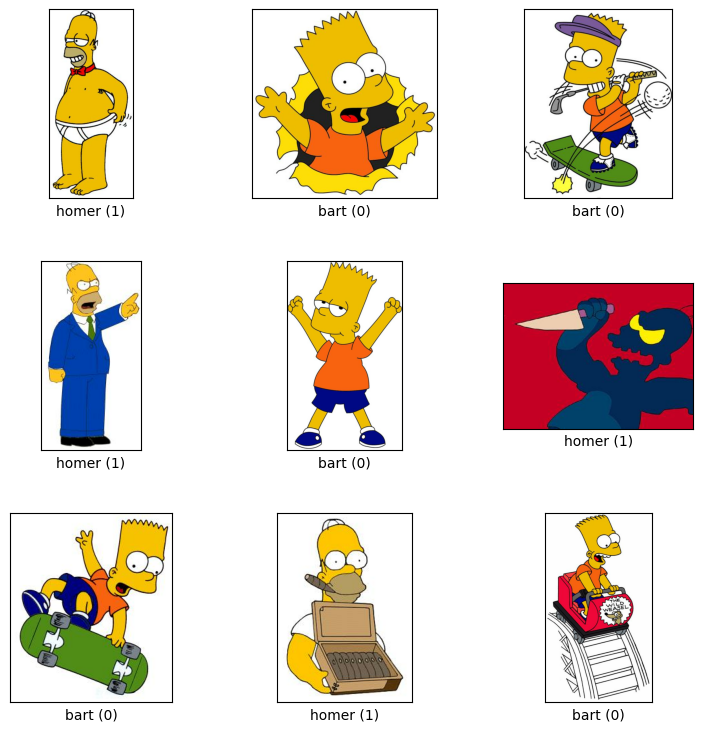

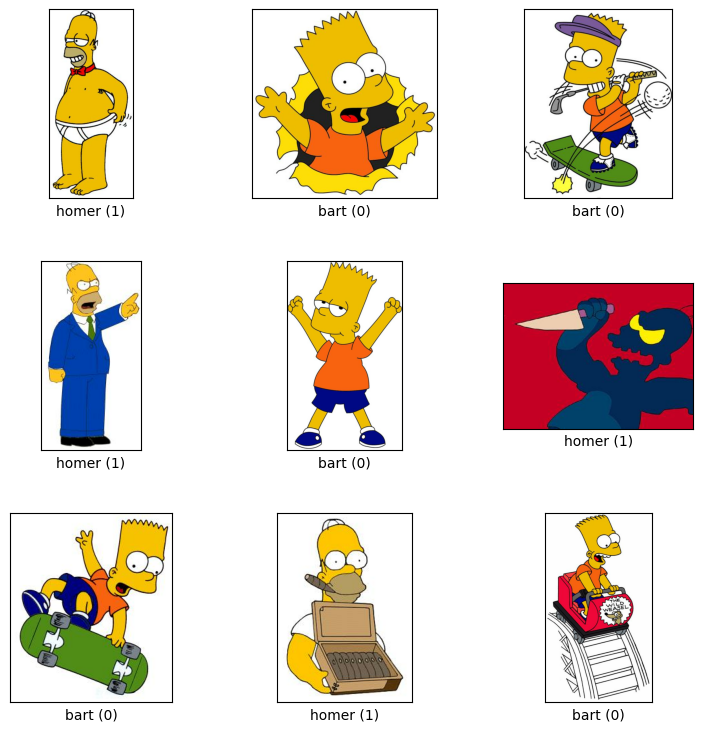

In [ ]:
import tensorflow_datasets as tfds

build = tfds.ImageFolder('/content/images')

train_data = build.as_dataset(split='train', shuffle_files=True)
test_data = build.as_dataset(split='test', shuffle_files=True)

print(build.info.features["label"].names)
tfds.show_examples(train_data, build.info)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.4500 - loss: 0.7226 - val_accuracy: 0.3951 - val_loss: 0.6878
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.8500 - loss: 0.5038 - val_accuracy: 0.6173 - val_loss: 0.8764
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7500 - loss: 0.6743 - val_accuracy: 0.6173 - val_loss: 0.7969
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.5000 - loss: 0.9221 - val_accuracy: 0.3827 - val_loss: 0.7833
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.5500 - loss: 0.8159 - val_accuracy: 0.9383 - val_loss: 0.4361
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.7000 - loss: 0.4620 - val_accuracy: 0.7901 - val_loss: 0.4083
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.8000 - loss: 0.5016 - val_accuracy: 0.8765 - val_loss: 0.3675
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.9000 - loss: 0.4950 - val_accuracy: 0.8765 - val_loss: 0.3761
Epoch 9/

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.6250 - loss: 0.4969 - val_accuracy: 0.8765 - val_loss: 0.3158


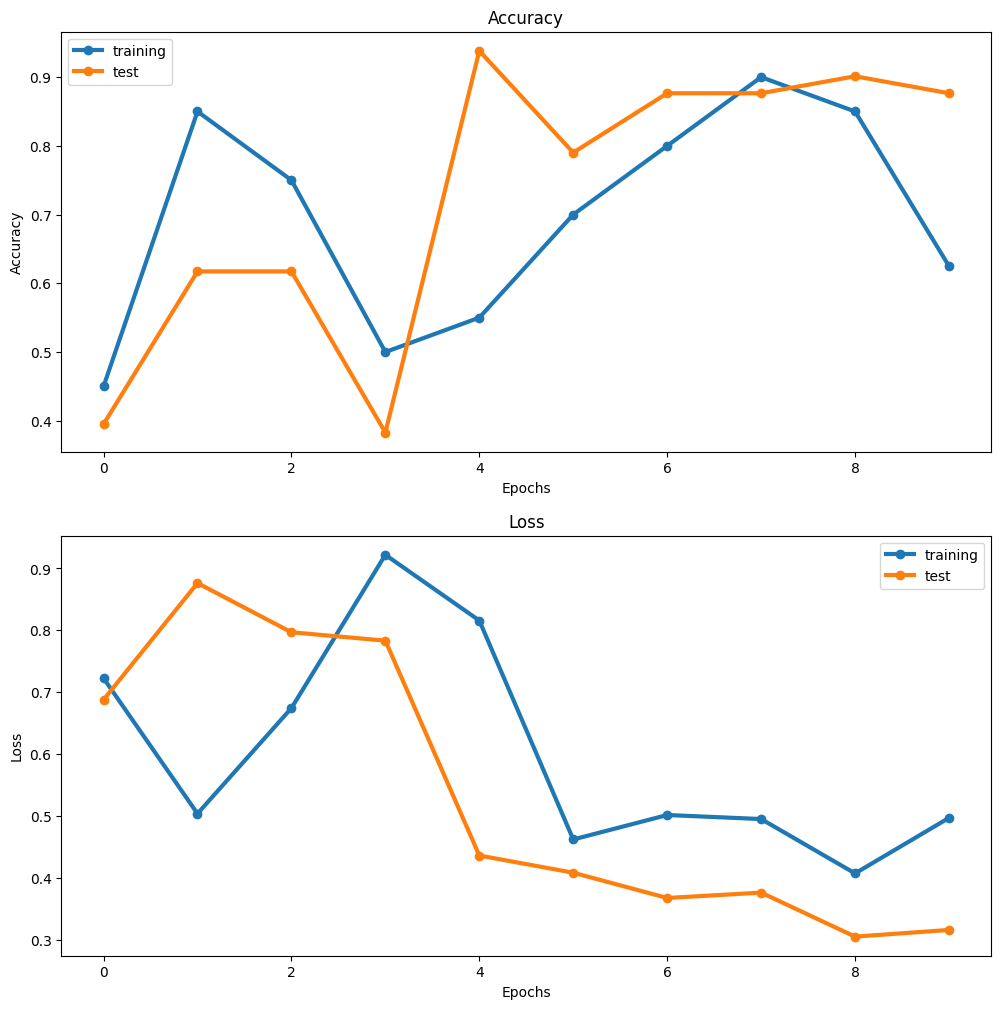

In [ ]:
#Learn a classifier by finetuning a BiT-M model (ResNet50x1 model trained on ImageNet-21k)
module=hub.KerasLayer("https://tfhub.dev/google/bit/m-r50x1/1")
#Create a new model with a new final layer that has the correct number of output classes
class BiT(tf.keras.Model):
  def __init__(self, num_classes, mod):
    super().__init__()
    self.num_classes=num_classes
    self.head=tf.keras.layers.Dense(num_classes,kernel_initializer='zeros')
    self.bit_model=mod

  def call(self,images):
    bit_embedding = self.bit_model(images)
    return self.head(bit_embedding)
model=BiT(num_classes=2,mod=module)

#Fine-tune this model using BiT-HyperRule
image_size = "=<96x96 px"
#Alternatively, set image_size = "> 96 x 96 px" #@param ["=<96x96 px","> 96 x 96 px"]
dataset_size = "\u003C20k examples" #@param ["<20k examples", "20k-500k examples", ">500k examples"]
#Resize and crop images

#if image_size == "=<96x96 px":
#  resize_to = 160
#  crop_to = 128
#else:
#  resize_to = 512
#  crop_to = 480

resize_to = 160
crop_to = 128

#Training steps
if dataset_size == "<20k examples":
  schedule_length = 500
  schedule_boundaries = [200, 300, 400]
elif dataset_size == "20k-500k examples":
  schedule_length = 10000
  schedule_boundaries = [3000, 6000, 9000]
else:
  schedule_length = 20000
  schedule_boundaries = [6000, 12000, 18000]


#Preprocessing
#batch_size = 10
batch_size = 4
schedule_length = schedule_length * 512 / batch_size
#steps_per_epoch= 10
steps_per_epoch= 5


def cast_to_tuple(features):
  return (features['image'], features['label'])

#Preprocess train  images
def preprocess_train(features):
  #Apply horizontal flips
  features['image'] = tf.image.random_flip_left_right(features['image'])
  #Resize
  features['image'] = tf.image.resize(features['image'], [resize_to, resize_to])
  #Apply random crop
  features['image'] = tf.image.random_crop(features['image'], [crop_to, crop_to, 3])
  #Min-max scaling
  features['image'] = tf.cast(features['image'], tf.float32) / 255.0
  return features
#Preprocess test images
def preprocess_test(features):
  #Resize
  features['image'] = tf.image.resize(features['image'], [resize_to, resize_to])
  #Min-max scaling
  features['image'] = tf.cast(features['image'], tf.float32) / 255.0
  return features
#Pipelines
num_train_examples=build.info.splits['train'].num_examples
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_pipeline = (train_data
                  #.shuffle(1000)
                  .shuffle(200)
                  #.repeat(int(schedule_length * batch_size / num_train_examples * steps_per_epoch))
                  .map(preprocess_train)
                  .batch(batch_size)
                  .map(cast_to_tuple)
                  #.prefetch(AUTOTUNE))
                  .prefetch(1))

test_pipeline = (test_data
                 .map(preprocess_test)
                 .batch(batch_size)
                 .map(cast_to_tuple)
                 .prefetch(AUTOTUNE))


#Fine-tuning loop
#learning rate
lr = 0.003 * batch_size / 512
#we decay the learning rate by a factor of 10 at 30%, 60% and 90% of the training steps (schedule_boundaries)
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=schedule_boundaries,
                                                                  values=[lr, lr*0.1, lr*0.001, lr*0.0001])
#we use SGD with lr_schedule learning rate and momentum 0.9
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
#loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
#compile the model
model.compile(optimizer=optimizer,
             loss=loss_fn,
             metrics=['accuracy'])

#Fine-tune model
history=model.fit(
   train_pipeline,
   #batch_size=10,
   epochs=10,
   #steps_per_epoch=10,
   steps_per_epoch=steps_per_epoch,
   validation_data=test_pipeline)

#learning curve
def learning_curve(history, lw = 3):
    plt.figure(figsize=(12,12))
    plt.subplot(2,1,1)
    plt.plot(history.history['accuracy'], label = 'training', marker = 'o', linewidth = lw)
    plt.plot(history.history['val_accuracy'], label = 'test', marker = 'o', linewidth = lw)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()


    plt.subplot(2,1,2)
    plt.plot(history.history['loss'], label = 'training', marker = 'o', linewidth = lw)
    plt.plot(history.history['val_loss'], label = 'test', marker = 'o', linewidth = lw)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

learning_curve(history)
